In [1]:
from src.FractionsCorrelation import (
    measure_correlations_by_L_and_gap,
    summarize_gap_independence,
    read_fraction_values_by_L_and_gap,
)
import json
import matplotlib.pyplot as plt
import lzma

In [2]:
corr = measure_correlations_by_L_and_gap(
    "../SOP_data",
    measure="p_stab_bond",
    L_values=16384,
    gaps=[0.5, 1.0, 1.5, 2.0],
    lags=range(1, 11),
)

summary = summarize_gap_independence(corr)

summary[[
    "L", "gap",
    "max_abs_correlation",
    "mean_abs_correlation",
    "min_p_value",
    "gap_rank",
    "is_best_gap",
]]

,L,gap,max_abs_correlation,mean_abs_correlation,min_p_value,gap_rank,is_best_gap
0,16384,1.5,1.0,0.472482,0.139183,1,True
1,16384,1.0,NaN,NaN,NaN,2,False


p_mean = 0.5021502633528276 ± 0.0015610477465115328, σ = 0.03660981476037272
p_mean = 0.4311572236696062 ± 0.0014410954042292094, σ = 0.04019597168949206
p_mean = 0.37281855232232103 ± 0.002473316426127827, σ = 0.04182757613242209
p_mean = 0.3289273051980013 ± 0.0031581584263178936, σ = 0.040812401250547525
p_mean = 0.2650416813790798 ± 0.01685186993570593, σ = 0.05329029182974601


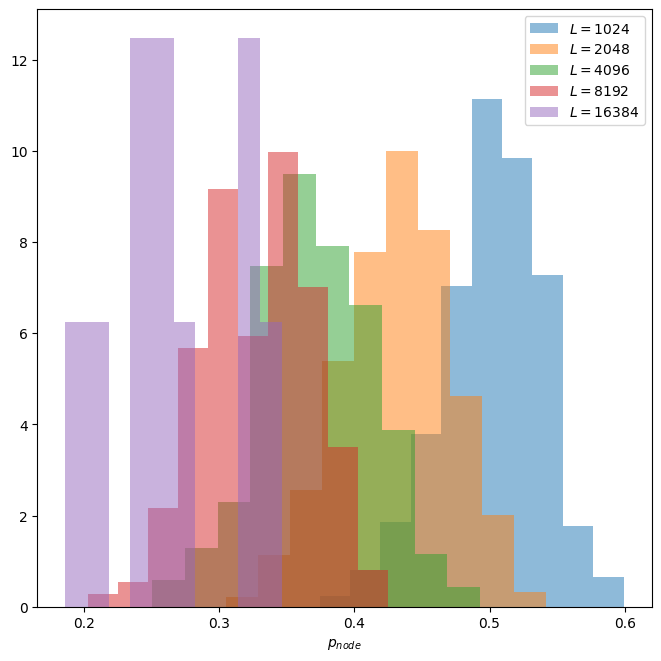

In [6]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]

base = 6.5
n_rows = 1
n_columns = 1

fs_title = 20
fs_label = 18
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*base, n_rows*base), constrained_layout=True)

gap = 1.5
prop = "p_inst_node"
p_mean_node = []
p_mean_erro = []
for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    p_stab = values[(L, gap)][0]["data"][prop]
    p_avarage = np.mean(p_stab)
    std = np.std(p_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))
    
    p_mean_node.append(p_avarage)
    p_mean_erro.append(sem)
    print(f"p_mean = {p_avarage} ± {sem}, σ = {std}")
    axes.hist(p_stab,alpha=0.5, density=True ,label=f"$L={L}$")
    axes.set_xlabel(r'$p_{node}$')
plt.legend()
plt.show()

p_mean = 0.3036852069408669 ± 0.0005686408562235234, σ = 0.013335810168551518
p_mean = 0.26865408036994337 ± 0.0005303369646123264, σ = 0.014792504058293174
p_mean = 0.2371777998772465 ± 0.0010156479689677222, σ = 0.01717616569273603
p_mean = 0.21161461355330505 ± 0.0016048837765840229, σ = 0.020739669075691962
p_mean = 0.1766245644853721 ± 0.008366317746376724, σ = 0.026456619707237377


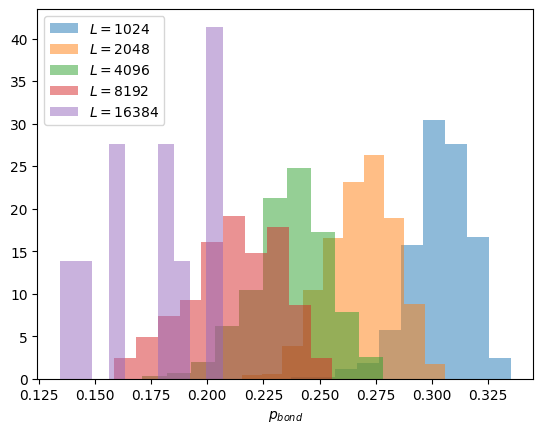

In [7]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.5
prop = "p_stab_bond"
p_mean_bond = []

for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    p_stab = values[(L, gap)][0]["data"][prop]
    p_avarage = np.mean(p_stab)
    std = np.std(p_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))
    p_mean_bond.append(p_avarage)
    
    print(f"p_mean = {p_avarage} ± {sem}, σ = {std}")
    plt.hist(p_stab, alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$p_{bond}$')
plt.legend()
plt.show()

In [8]:
#p_mean_node
R = [i/j for i,j in zip(p_mean_node, p_mean_bond)]
R

[1.6535223049261187,
 1.604878746214805,
 1.5718948085161286,
 1.554369519547125,
 1.5005935451352823]

p_mean = 0.3036852069408669 ± 0.0005686408562235234, σ = 0.013335810168551518
p_mean = 0.26865408036994337 ± 0.0005303369646123264, σ = 0.014792504058293174
p_mean = 0.2371777998772465 ± 0.0010156479689677222, σ = 0.01717616569273603
p_mean = 0.21161461355330505 ± 0.0016048837765840229, σ = 0.020739669075691962
p_mean = 0.1766245644853721 ± 0.008366317746376724, σ = 0.026456619707237377


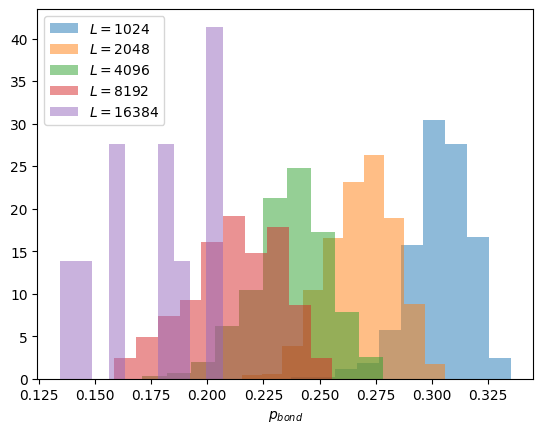

In [9]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.5
prop = "p_stab_bond"
p_mean_bond = []
p_mean_err = []
for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    p_stab = values[(L, gap)][0]["data"][prop]
    p_avarage = np.mean(p_stab)
    std = np.std(p_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))
    p_mean_bond.append(p_avarage)
    p_mean_err.append(sem)
    print(f"p_mean = {p_avarage} ± {sem}, σ = {std}")
    plt.hist(p_stab, alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$p_{bond}$')
plt.legend()
plt.show()

In [10]:
def formatar_parametro(valor, erro, algarismos_erro=2):
    """
    Formata valor e erro sem notação científica.
    O erro é mostrado com dois algarismos significativos.
    """
    if not np.isfinite(erro) or erro <= 0:
        return f"{valor:.4f}", f"{erro:.4f}"

    ordem = np.floor(np.log10(abs(erro)))
    casas = max(0, int(-ordem + algarismos_erro - 1))

    return (
        f"{valor:.{casas}f}",
        f"{erro:.{casas}f}"
    )

A = 1.494282 ± 0.000000
d = 1.781764 ± 0.000000
R² = 0.999344
RMSE(log) = 4.541512e-02
χ² reduzido = 2963437786169269.500000


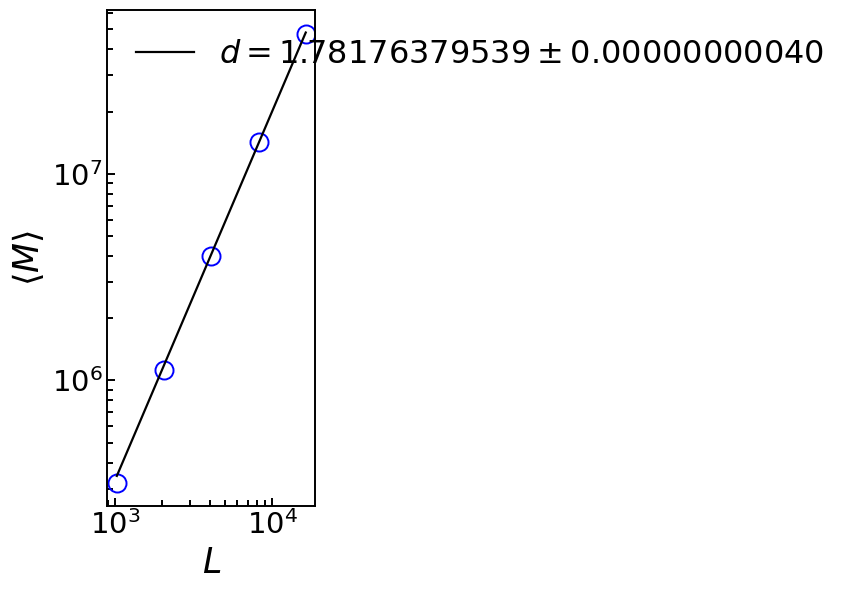

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.asarray(L_lst, dtype=float)
y = np.asarray(p_mean_bond, dtype=float)*x**2
y_err = np.asarray(p_mean_erro, dtype=float)

# Remove valores inválidos para o ajuste log-log
mask = (
    np.isfinite(x)
    & np.isfinite(y)
    & np.isfinite(y_err)
    & (x > 0)
    & (y > 0)
    & (y_err > 0)
)

x = x[mask]
y = y[mask]
y_err = y_err[mask]

# Transformação logarítmica
x_log = np.log(x)
y_log = np.log(y)

# Propagação da incerteza:
# sigma[ln(y)] ≈ sigma_y/y
y_log_err = y_err / y


# Modelo linear no espaço logarítmico
def linear_log(x_log, log_A, d):
    return log_A + d * x_log


# Ajuste ponderado
popt, pcov = curve_fit(
    linear_log,
    x_log,
    y_log,
    sigma=y_log_err,
    absolute_sigma=True
)

log_A, d = popt

# Incertezas e covariância
log_A_err, d_err = np.sqrt(np.diag(pcov))
cov_logA_d = pcov[0, 1]

# Conversão de log(A) para A
A = np.exp(log_A)
A_err = A * log_A_err

# Predição
y_pred_log = linear_log(x_log, log_A, d)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

# Qui-quadrado
chi2 = np.sum(((y_log - y_pred_log) / y_log_err)**2)
ndof = len(x) - len(popt)
chi2_red = chi2 / ndof if ndof > 0 else np.nan

print(f"A = {A:.6f} ± {A_err:.6f}")
print(f"d = {d:.6f} ± {d_err:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")
print(f"χ² reduzido = {chi2_red:.6f}")

# Curva ajustada
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

base = 3
fig, ax = plt.subplots(figsize=(2 * base, 2 * base))

ax.plot(
    x,
    y,
    linestyle='none',
    marker='o',
    markersize=13,
    markeredgecolor='blue',
    markerfacecolor='none',
    markeredgewidth=1.4
)
A_texto, A_erro_texto = formatar_parametro(A, A_err)
d_texto, d_erro_texto = formatar_parametro(d, d_err)

legenda = (
    
    fr'$d = {d_texto}\pm {d_erro_texto}$'
)
ax.plot(
    L_fit,
    S_fit,
    '-',
    color='k',
    linewidth=1.6,
    label=legenda
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=25)
ax.set_ylabel(r'$\langle M \rangle$', fontsize=25)

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    labelsize=21,
    length=6,
    width=1.4
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.4
)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

# Legenda sem caixa
ax.legend(
    fontsize=23,
    frameon=False,
    loc='upper left',
    handlelength=1.8
)

fig.tight_layout()
plt.savefig("../results/1Color/2D/properties/Biggest_component.pdf")
plt.show()

S_mean = 71905.97727272728 ± 5410.539566543358, σ = 17109.62840073717
S_mean = 388602.0363636364 ± 29885.162242033322, σ = 94505.18092848954
S_mean = 1532406.9562982004 ± 111913.51397417075, σ = 353901.60511146195
S_mean = 5858094.832167832 ± 377212.2194739105, σ = 1192849.774784879
S_mean = 20585466.48502994 ± 1509865.945774656, σ = 4774615.3501721965
S_mean = 77591415.0 ± 5515256.619219567, σ = 17440772.797053818


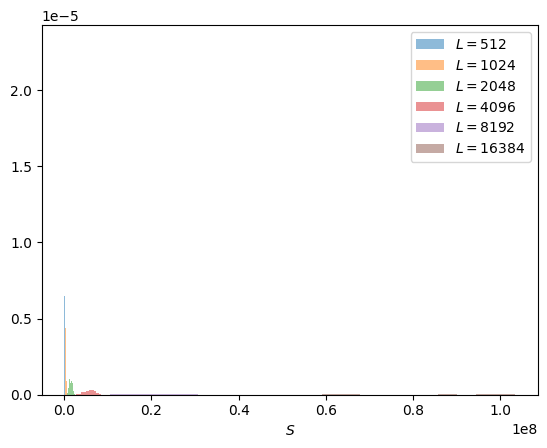

In [14]:
import numpy as np
L_lst = [512, 1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.5
prop = "S_stab"
S_mean = []
S_mean_err = []

for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    s_stab = values[(L, gap)][0]["data"][prop]
    s_avarage = np.mean(s_stab)

    std = np.std(s_stab, ddof=1)
    sem = std / np.sqrt(np.size(p_stab))

    S_mean.append(s_avarage)
    S_mean_err.append(sem)
    
    print(f"S_mean = {s_avarage} ± {sem}, σ = {std}")
    plt.hist(s_stab, alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$S$')
plt.legend()
plt.show()

# Fractal Dimension

A = 0.367121 ± 0.075564
d = 1.984568 ± 0.025357
R² = 0.997588
RMSE(log) = 1.155668e-01
χ² reduzido = 3.692527


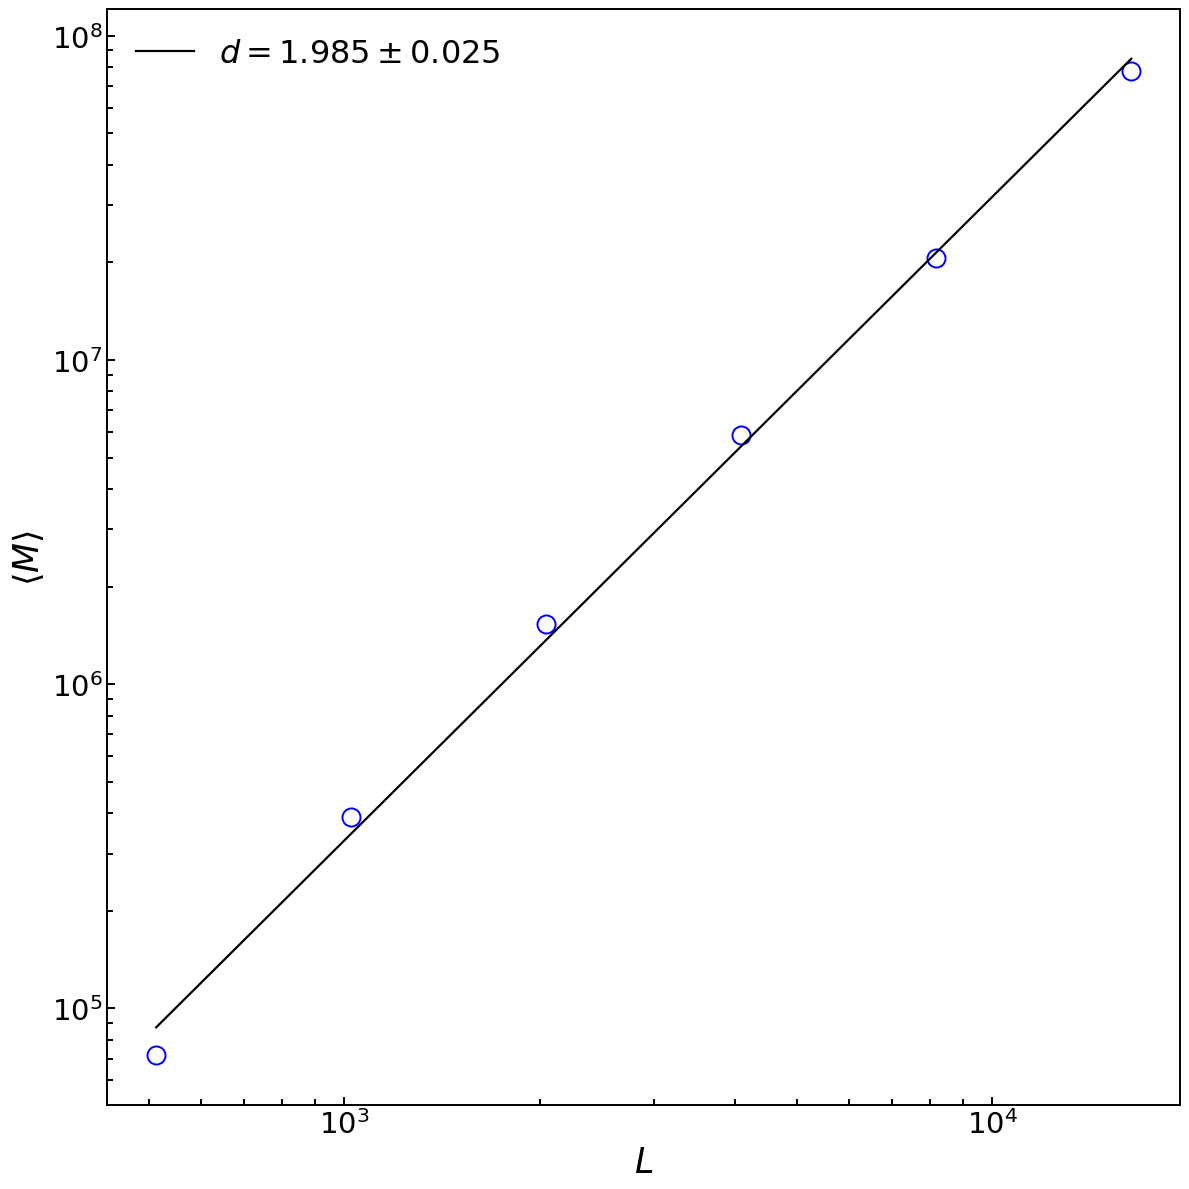

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.asarray(L_lst, dtype=float)
y = np.asarray(S_mean, dtype=float)
y_err = np.asarray(S_mean_err, dtype=float)

# Remove valores inválidos para o ajuste log-log
mask = (
    np.isfinite(x)
    & np.isfinite(y)
    & np.isfinite(y_err)
    & (x > 0)
    & (y > 0)
    & (y_err > 0)
)

x = x[mask]
y = y[mask]
y_err = y_err[mask]

# Transformação logarítmica
x_log = np.log(x)
y_log = np.log(y)

# Propagação da incerteza:
# sigma[ln(y)] ≈ sigma_y/y
y_log_err = y_err / y


# Modelo linear no espaço logarítmico
def linear_log(x_log, log_A, d):
    return log_A + d * x_log


# Ajuste ponderado
popt, pcov = curve_fit(
    linear_log,
    x_log,
    y_log,
    sigma=y_log_err,
    absolute_sigma=True
)

log_A, d = popt

# Incertezas e covariância
log_A_err, d_err = np.sqrt(np.diag(pcov))
cov_logA_d = pcov[0, 1]

# Conversão de log(A) para A
A = np.exp(log_A)
A_err = A * log_A_err

# Predição
y_pred_log = linear_log(x_log, log_A, d)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

# Qui-quadrado
chi2 = np.sum(((y_log - y_pred_log) / y_log_err)**2)
ndof = len(x) - len(popt)
chi2_red = chi2 / ndof if ndof > 0 else np.nan

print(f"A = {A:.6f} ± {A_err:.6f}")
print(f"d = {d:.6f} ± {d_err:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")
print(f"χ² reduzido = {chi2_red:.6f}")

# Curva ajustada
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d
A_texto, A_erro_texto = formatar_parametro(A, A_err)
d_texto, d_erro_texto = formatar_parametro(d, d_err)

legenda = (
    
    fr'$d = {d_texto}\pm {d_erro_texto}$'
)
base = 6
fig, ax = plt.subplots(figsize=(2 * base, 2 * base))

ax.plot(
    x,
    y,
    linestyle='none',
    marker='o',
    markersize=13,
    markeredgecolor='blue',
    markerfacecolor='none',
    markeredgewidth=1.4
)

ax.plot(
    L_fit,
    S_fit,
    '-',
    color='k',
    linewidth=1.6,
    label=legenda
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=25)
ax.set_ylabel(r'$\langle M \rangle$', fontsize=25)

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    labelsize=21,
    length=6,
    width=1.4
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.4
)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

# Legenda sem caixa
ax.legend(
    fontsize=23,
    frameon=False,
    loc='upper left',
    handlelength=1.8
)

fig.tight_layout()
#plt.savefig("../results/1Color/2D/properties/Biggest_component.pdf")
plt.show()

# Shortest Path

874.8990909090909
2449.1672727272726
5623.363753213368
12974.066433566433
28455.988023952097
68471.4


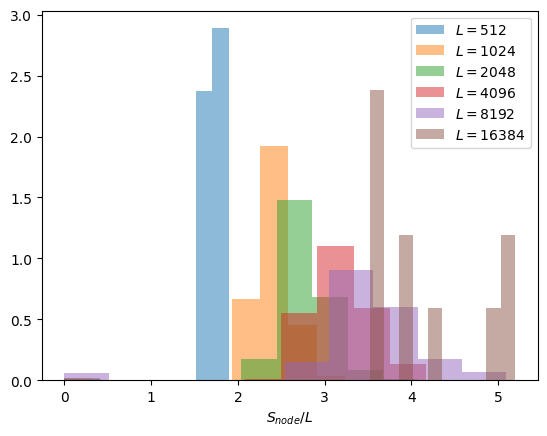

In [16]:
import numpy as np
L_lst = [512, 1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.5
prop = "SP_stab"
SP_mean = []
SP_mean_err = []

for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    SP_stab = values[(L, gap)][0]["data"][prop]
    norm = [i/L for i in SP_stab]
    SP_avarage = np.mean(SP_stab)

    std = np.std(SP_stab, ddof=1)
    sem = std / np.sqrt(np.size(SP_stab))

    SP_mean_err.append(sem)
    SP_mean.append(SP_avarage)

    print(SP_avarage)
    plt.hist(norm,alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$S_{node}/L$')
plt.legend()
plt.show()

A = 0.231859 ± 0.003544
d = 1.321696 ± 0.002337
R² = 0.991865
RMSE(log) = 1.321146e-01
χ² reduzido = 198.819343


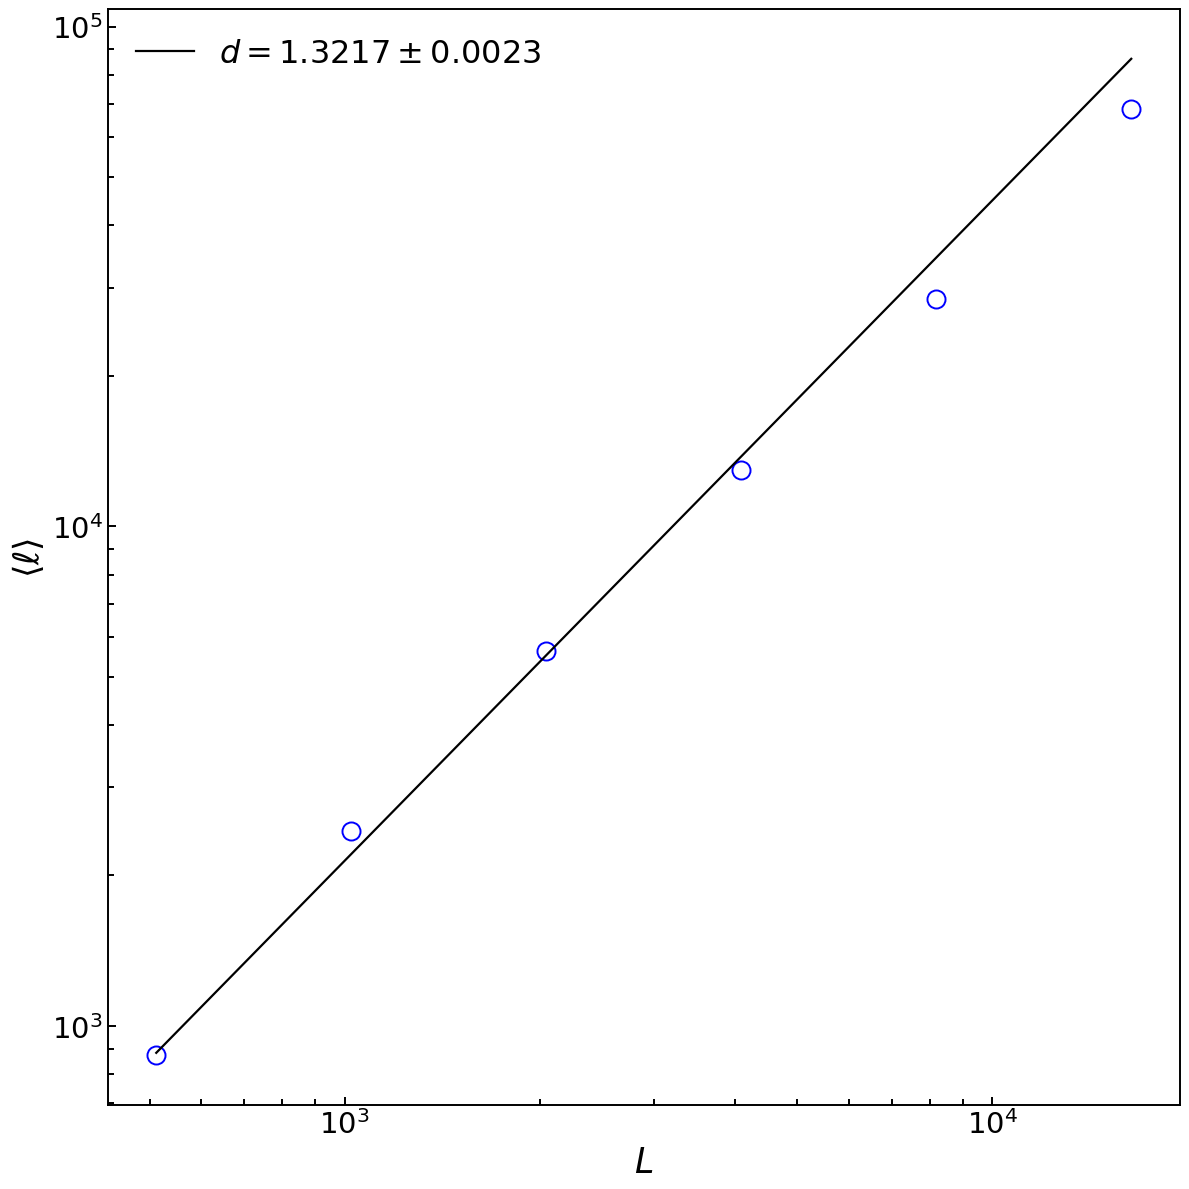

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.asarray(L_lst, dtype=float)
y = np.asarray(SP_mean, dtype=float)
y_err = np.asarray(SP_mean_err, dtype=float)

# Remove valores inválidos para o ajuste log-log
mask = (
    np.isfinite(x)
    & np.isfinite(y)
    & np.isfinite(y_err)
    & (x > 0)
    & (y > 0)
    & (y_err > 0)
)

x = x[mask]
y = y[mask]
y_err = y_err[mask]

# Transformação logarítmica
x_log = np.log(x)
y_log = np.log(y)

# Propagação da incerteza:
# sigma[ln(y)] ≈ sigma_y/y
y_log_err = y_err / y


# Modelo linear no espaço logarítmico
def linear_log(x_log, log_A, d):
    return log_A + d * x_log


# Ajuste ponderado
popt, pcov = curve_fit(
    linear_log,
    x_log,
    y_log,
    sigma=y_log_err,
    absolute_sigma=True
)

log_A, d = popt

# Incertezas e covariância
log_A_err, d_err = np.sqrt(np.diag(pcov))
cov_logA_d = pcov[0, 1]

# Conversão de log(A) para A
A = np.exp(log_A)
A_err = A * log_A_err

# Predição
y_pred_log = linear_log(x_log, log_A, d)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

# Qui-quadrado
chi2 = np.sum(((y_log - y_pred_log) / y_log_err)**2)
ndof = len(x) - len(popt)
chi2_red = chi2 / ndof if ndof > 0 else np.nan

print(f"A = {A:.6f} ± {A_err:.6f}")
print(f"d = {d:.6f} ± {d_err:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")
print(f"χ² reduzido = {chi2_red:.6f}")

# Curva ajustada
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d
A_texto, A_erro_texto = formatar_parametro(A, A_err)
d_texto, d_erro_texto = formatar_parametro(d, d_err)

legenda = (
    
    fr'$d = {d_texto}\pm {d_erro_texto}$'
)
base = 6
fig, ax = plt.subplots(figsize=(2 * base, 2 * base))

ax.plot(
    x,
    y,
    linestyle='none',
    marker='o',
    markersize=13,
    markeredgecolor='blue',
    markerfacecolor='none',
    markeredgewidth=1.4
)

ax.plot(
    L_fit,
    S_fit,
    '-',
    color='k',
    linewidth=1.6,
    label=legenda
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=25)
ax.set_ylabel(r'$\langle \ell \rangle$', fontsize=25)

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    labelsize=21,
    length=6,
    width=1.4
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.4
)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

# Legenda sem caixa
ax.legend(
    fontsize=23,
    frameon=False,
    loc='upper left',
    handlelength=1.8
)

fig.tight_layout()
plt.savefig("../results/1Color/2D/properties/Shortest_path.pdf")
plt.show()

4099.614545454546
16793.05818181818
44033.35218508998
115347.71328671329
298071.377245509
829258.8


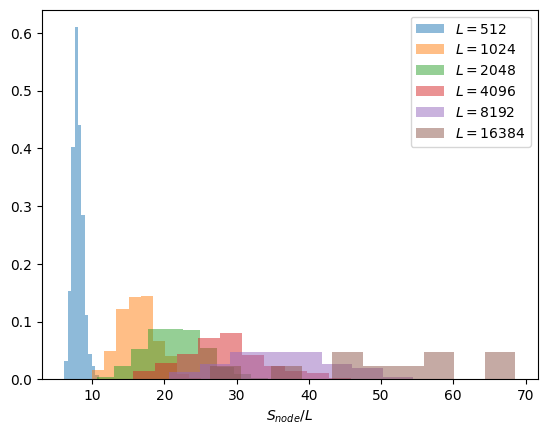

In [18]:
import numpy as np
L_lst = [512, 1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.5
prop = "hull_length"
HULL_mean = []
HULL_mean_err = []

for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    HULL_stab = values[(L, gap)][0]["data"][prop]
    norm = [i/L for i in HULL_stab]
    HULL_avarage = np.mean(HULL_stab)
    
    std = np.std(HULL_stab, ddof=1)
    sem = std / np.sqrt(np.size(HULL_stab))

    HULL_mean_err.append(sem)
    HULL_mean.append(HULL_avarage)

    print(HULL_avarage)
    plt.hist(norm, alpha=0.5, density=True ,label=f"$L={L}$")
    plt.xlabel(r'$S_{node}/L$')
plt.legend()
plt.show()

A = 0.146079 ± 0.003255
d = 1.647122 ± 0.003346
R² = 0.980842
RMSE(log) = 2.446711e-01
χ² reduzido = 496.242906


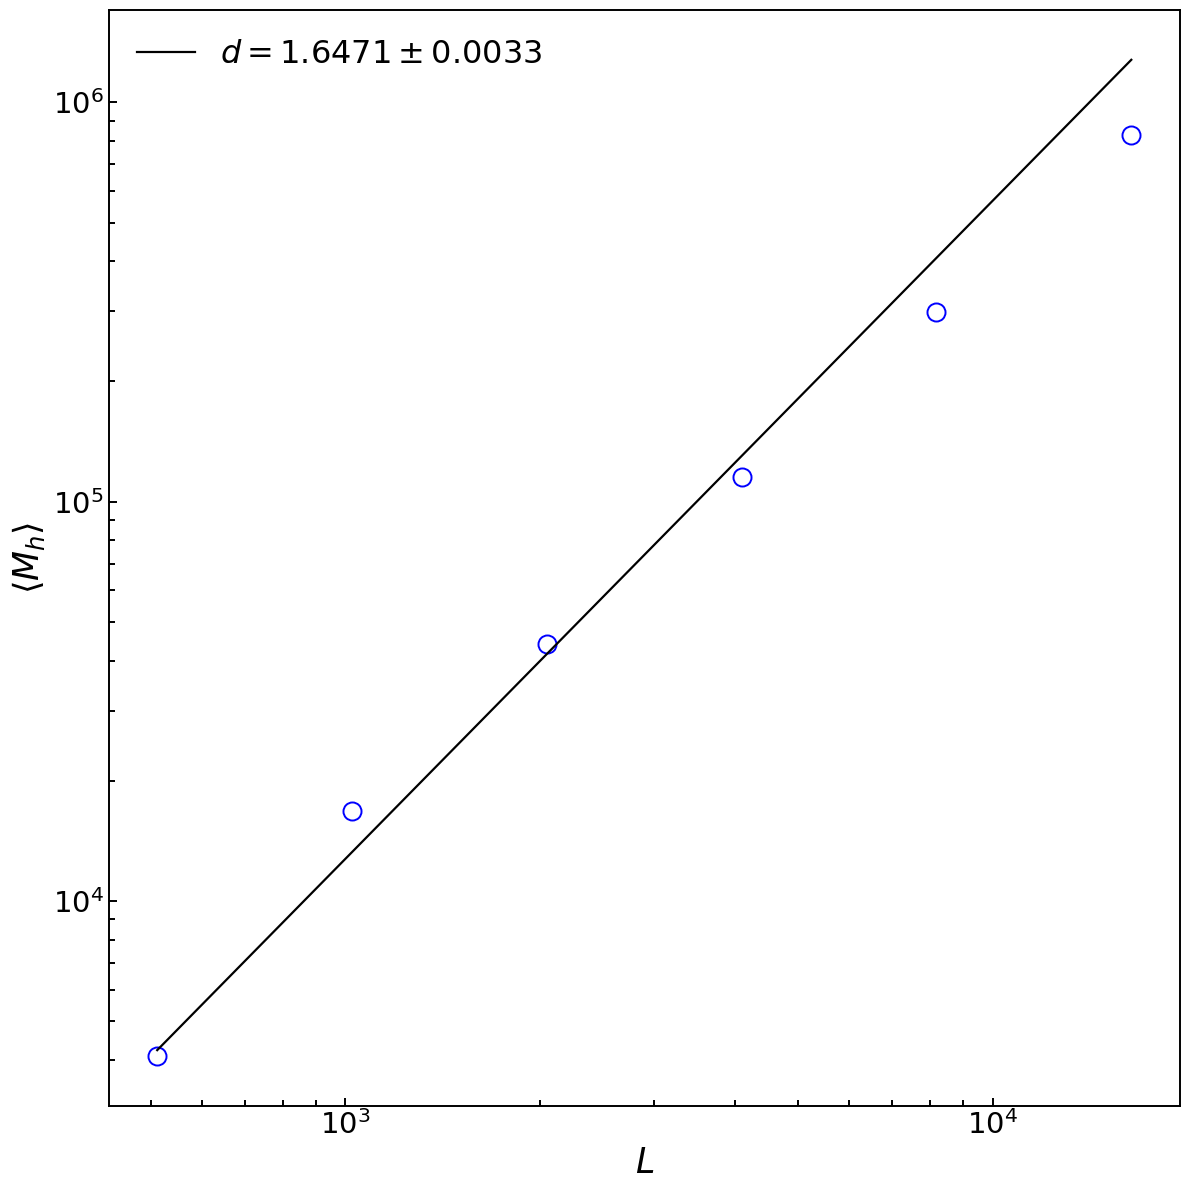

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score

# Dados
x = np.asarray(L_lst, dtype=float)
y = np.asarray(HULL_mean, dtype=float)
y_err = np.asarray(HULL_mean_err, dtype=float)

# Remove valores inválidos para o ajuste log-log
mask = (
    np.isfinite(x)
    & np.isfinite(y)
    & np.isfinite(y_err)
    & (x > 0)
    & (y > 0)
    & (y_err > 0)
)

x = x[mask]
y = y[mask]
y_err = y_err[mask]

# Transformação logarítmica
x_log = np.log(x)
y_log = np.log(y)

# Propagação da incerteza:
# sigma[ln(y)] ≈ sigma_y/y
y_log_err = y_err / y


# Modelo linear no espaço logarítmico
def linear_log(x_log, log_A, d):
    return log_A + d * x_log


# Ajuste ponderado
popt, pcov = curve_fit(
    linear_log,
    x_log,
    y_log,
    sigma=y_log_err,
    absolute_sigma=True
)

log_A, d = popt

# Incertezas e covariância
log_A_err, d_err = np.sqrt(np.diag(pcov))
cov_logA_d = pcov[0, 1]

# Conversão de log(A) para A
A = np.exp(log_A)
A_err = A * log_A_err

# Predição
y_pred_log = linear_log(x_log, log_A, d)

# Métricas no espaço log
r2 = r2_score(y_log, y_pred_log)
rmse = np.sqrt(mean_squared_error(y_log, y_pred_log))

# Qui-quadrado
chi2 = np.sum(((y_log - y_pred_log) / y_log_err)**2)
ndof = len(x) - len(popt)
chi2_red = chi2 / ndof if ndof > 0 else np.nan

print(f"A = {A:.6f} ± {A_err:.6f}")
print(f"d = {d:.6f} ± {d_err:.6f}")
print(f"R² = {r2:.6f}")
print(f"RMSE(log) = {rmse:.6e}")
print(f"χ² reduzido = {chi2_red:.6f}")

# Curva ajustada
L_fit = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    200
)

S_fit = A * L_fit**d

base = 6
fig, ax = plt.subplots(figsize=(2 * base, 2 * base))

ax.plot(
    x,
    y,
    linestyle='none',
    marker='o',
    markersize=13,
    markeredgecolor='blue',
    markerfacecolor='none',
    markeredgewidth=1.4
)

A_texto, A_erro_texto = formatar_parametro(A, A_err)
d_texto, d_erro_texto = formatar_parametro(d, d_err)

legenda = (
    
    fr'$d = {d_texto}\pm {d_erro_texto}$'
)

ax.plot(
    L_fit,
    S_fit,
    '-',
    color='k',
    linewidth=1.6,
    label=legenda
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$L$', fontsize=25)
ax.set_ylabel(r'$\langle M_h \rangle$', fontsize=25)

ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    labelsize=21,
    length=6,
    width=1.4
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.4
)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

# Legenda sem caixa
ax.legend(
    fontsize=23,
    frameon=False,
    loc='upper left',
    handlelength=1.8
)

fig.tight_layout()
plt.savefig("../results/1Color/2D/properties/HULL.pdf")
plt.show()

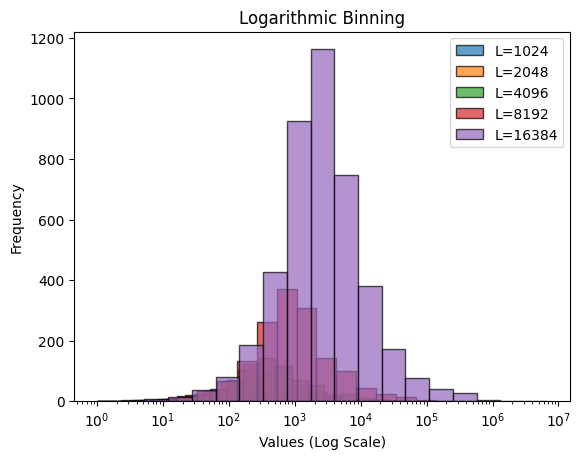

In [56]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.5
prop = "hole_size_counts"
HULL_mean = []
HULL_mean_err = []
L = 2048
#for L in L_lst:
for L in L_lst:
    values = read_fraction_values_by_L_and_gap(
    "../SOP_data",
    measures=prop,
    L_values=L,
    gaps=[gap],
    )
    hole = values[(L, gap)][0]["data"][prop][0]
    # Sizes of holes in network
    sizes = [int(key) for key,value in hole.items()]
    # Number of elements with sizes of holes in network
    n_sizes = [int(value) for key,value in hole.items()]

    min_val = max(min(sizes), 0.1)
    max_val = max(sizes)

    bins = np.logspace(np.log10(min_val), np.log10(max_val), 20)
    plt.hist(sizes, bins=bins, edgecolor='black', alpha=0.7, label=f'L={L}')

    # 3. Change the X-axis to log scale so intervals look uniform
plt.xscale('log')

plt.xlabel('Values (Log Scale)')
plt.ylabel('Frequency')
plt.title('Logarithmic Binning')
plt.legend()
plt.show()


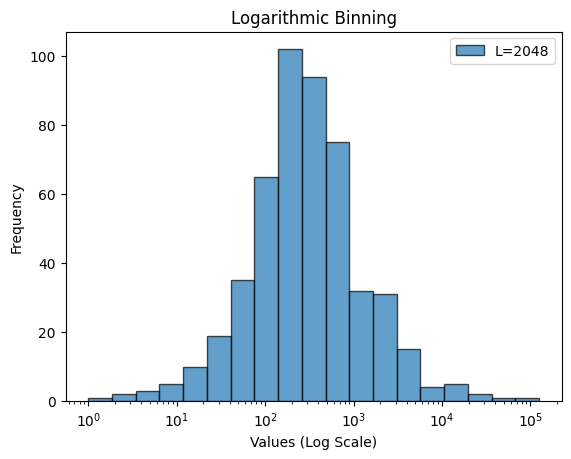

In [57]:
import numpy as np
L_lst = [1024, 2048, 4096, 8192,16384]
#gaps = [0.5, 1.0, 1.5, 2.0]
gap = 1.5
prop = "hole_size_counts"
HULL_mean = []
HULL_mean_err = []
L = 2048

values = read_fraction_values_by_L_and_gap(
"../SOP_data",
measures=prop,
L_values=L,
gaps=[gap],
)
hole = values[(L, gap)][0]["data"][prop][0]
# Sizes of holes in network
sizes = [int(key) for key,value in hole.items()]
# Number of elements with sizes of holes in network
n_sizes = [int(value) for key,value in hole.items()]

min_val = max(min(sizes), 0.1)
max_val = max(sizes)

bins = np.logspace(np.log10(min_val), np.log10(max_val), 20)
plt.hist(sizes, bins=bins, edgecolor='black', alpha=0.7, label=f'L={L}')

    # 3. Change the X-axis to log scale so intervals look uniform
plt.xscale('log')

plt.xlabel('Values (Log Scale)')
plt.ylabel('Frequency')
plt.title('Logarithmic Binning')
plt.legend()
plt.show()
